# Build ML model for analysis and prediction of DNA-encoded library data.

In [1]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import Descriptors, rdPartialCharges
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

import itertools
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import pathlib
from pathlib import Path
from rdkit import RDLogger
from tqdm.notebook import tqdm

# Get the main logger
logger = RDLogger.logger()

# Set its level to ERROR so only serious messages show up
logger.setLevel(RDLogger.ERROR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#verify Cuda is actually working

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (runtime):", torch.version.cuda)

print("Torch CUDA libraries loaded:")
for lib in torch.cuda._CudaBase.__module__.split(":"):
    print(lib)

Torch version: 2.8.0+cu128
CUDA available: True
CUDA version (runtime): 12.8
Torch CUDA libraries loaded:
torch.cuda


## Setup.

In [2]:
readout = 'kindel_del'

In [3]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

In [4]:
import s3fs

for dataset in ['ddr1', 'mapk14']: 
    fs = s3fs.S3FileSystem(anon=True)
    info = fs.info(f'kin-del-2024/data/{dataset}.parquet')
    print(f"File size for {dataset}: {info['size']/1e6:.2f} MB")

File size for ddr1: 6782.18 MB
File size for mapk14: 6911.55 MB


In [5]:
import pyarrow.parquet as pq

def read_first_n_rows(file_path, n_rows):
    parquet_file = pq.ParquetFile(file_path)
    
    num_row_groups = parquet_file.num_row_groups
    
    rows_read = 0
    result = []

    for i in range(num_row_groups):
        row_group = parquet_file.read_row_group(i)
        df = row_group.to_pandas()

        if rows_read + len(df) >= n_rows:
            result.append(df.head(n_rows - rows_read))
            break
        
        result.append(df)
        rows_read += len(df)

    final_df = pd.concat(result, ignore_index=True).head(n_rows)
    return final_df

In [6]:
def count_rows(file_path):
    parquet_file = pq.ParquetFile(file_path)
    total_rows = sum(parquet_file.metadata.row_group(i).num_rows
                     for i in range(parquet_file.num_row_groups))
    return total_rows

In [7]:
target = f"{DATA}/ddr1.parquet"

row_count = count_rows(target)
print(f"Total rows: {row_count}")

N = 1000  # Number of rows to load - for prototyping
df = read_first_n_rows(target, N)

Total rows: 67641617


2025-11-12 10:02:06.564216: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-12 10:02:06.825901: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by sett

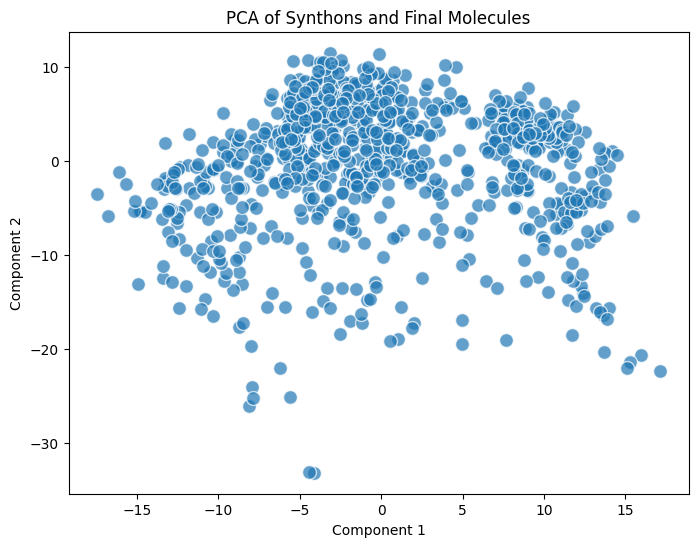

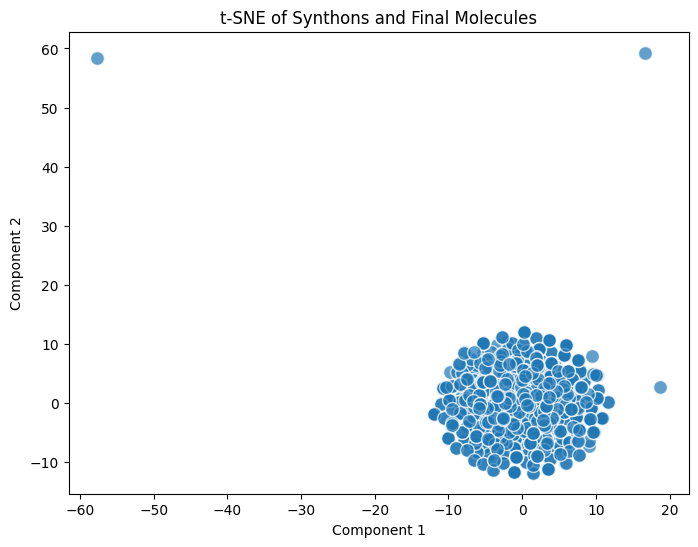

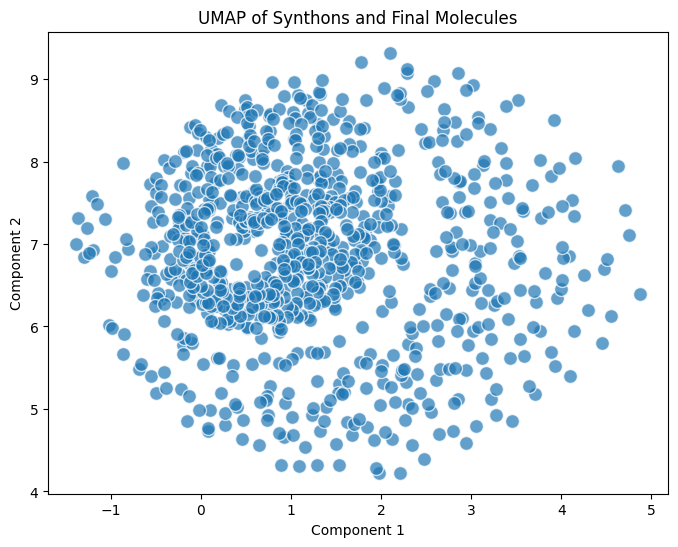

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')


# Define a function to compute Morgan fingerprints (a type of molecular fingerprint)
def compute_fingerprint(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits))
    else:
        return None

# Compute the fingerprints for each synthon and the final molecule
def get_fingerprints(df):
    df['fp_a'] = df['smiles_a'].apply(compute_fingerprint)
    df['fp_b'] = df['smiles_b'].apply(compute_fingerprint)
    df['fp_c'] = df['smiles_c'].apply(compute_fingerprint)
    df['fp_final'] = df['smiles'].apply(compute_fingerprint)
    
    # Drop rows where any fingerprint is missing
    df = df.dropna(subset=['fp_a', 'fp_b', 'fp_c', 'fp_final']).reset_index(drop=True)
    return df

# Apply to your DataFrame
df = get_fingerprints(df)

# Convert fingerprints to numpy arrays (bit vectors)
fingerprints = np.array([
    np.concatenate([row['fp_a'], row['fp_b'], row['fp_c'], row['fp_final']])
    for _, row in df.iterrows()
])
    
fingerprints = np.array(fingerprints)

# Normalize the data: PCA, t-SNE, and UMAP all work better with normalized data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
fingerprints_scaled = scaler.fit_transform(fingerprints)

# ---------------------------
# Apply PCA for dimensionality reduction
pca = PCA(n_components=2)
pca_result = pca.fit_transform(fingerprints_scaled)

# Apply t-SNE for non-linear dimensionality reduction
tsne = TSNE(n_components=2, perplexity=30, max_iter=300)
tsne_result = tsne.fit_transform(fingerprints_scaled)

# Apply UMAP for non-linear dimensionality reduction
umap_model = umap.UMAP(
    n_components=2,
    metric='jaccard',     # same as Tanimoto for bit vectors
    n_neighbors=30,       # tune: 10–50 usually
    min_dist=0.1,         # smaller = tighter clusters
    random_state=42
)
umap_result = umap_model.fit_transform(fingerprints_scaled)

# ---------------------------
# Plotting the results

# Function to plot results
def plot_2d_projection(X, title="Dimensionality Reduction", x_label="Component 1", y_label="Component 2"):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], alpha=0.7, edgecolors='w', s=100)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()

# Plot PCA result
plot_2d_projection(pca_result, title="PCA of Synthons and Final Molecules")

# Plot t-SNE result
plot_2d_projection(tsne_result, title="t-SNE of Synthons and Final Molecules")

# Plot UMAP result
plot_2d_projection(umap_result, title="UMAP of Synthons and Final Molecules")


In [20]:
# Compute means across triplicates
df['target_mean'] = df[['seq_target_1', 'seq_target_2', 'seq_target_3']].mean(axis=1)
df['matrix_mean'] = df[['seq_matrix_1', 'seq_matrix_2', 'seq_matrix_3']].mean(axis=1)

# Compute log10 enrichment (add 1 to avoid division by zero)
df['log_enrichment'] = np.log10((df['target_mean'] + 1) / (df['matrix_mean'] + 1))


In [21]:
def plot_2d_projection(X, color=None, title="Dimensionality Reduction",
                       x_label="Component 1", y_label="Component 2",
                       cmap='coolwarm'):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=color, cmap=cmap,
                          alpha=0.8, edgecolors='w', s=80)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    if color is not None:
        plt.colorbar(scatter, label='Color scale')
    plt.show()


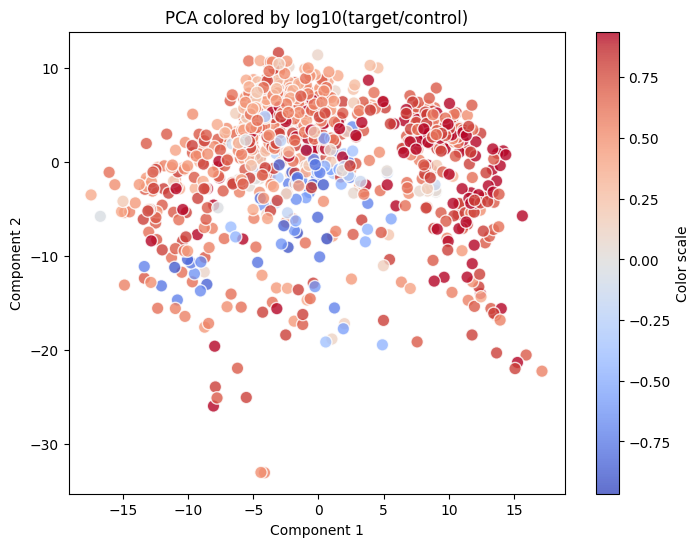

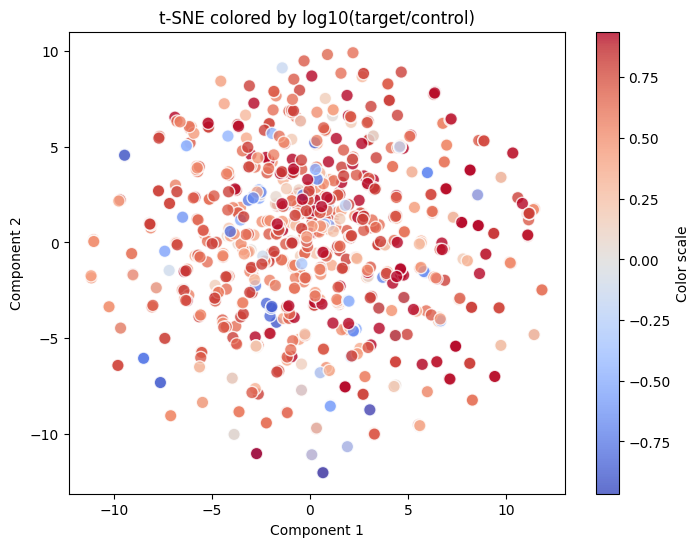

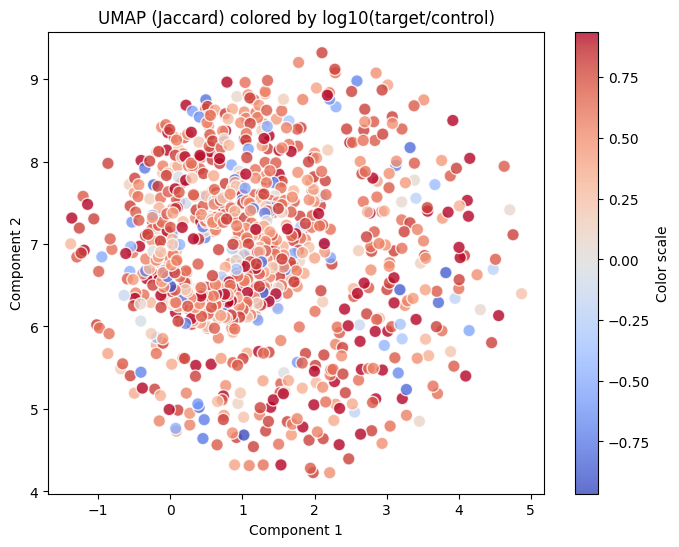

In [ ]:
plot_2d_projection(pca_result, color=df['log_enrichment'],
                   title="PCA colored by log10(target/control)")
plot_2d_projection(tsne_result, color=df['log_enrichment'],
                   title="t-SNE colored by log10(target/control)")
plot_2d_projection(umap_result, color=df['log_enrichment'],
                   title="UMAP (Jaccard) colored by log10(target/control)",
    cmap='coolwarm'
)


### Reporting template.

In [36]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=10)
df['cluster'] = db.fit_predict(umap_result)


In [37]:
cluster_summary = (
    df.groupby('cluster')
      .agg(mean_enrichment=('log_enrichment', 'mean'),
           n_molecules=('log_enrichment', 'count'))
      .sort_values('mean_enrichment', ascending=False)
)
print(cluster_summary.head(10))


         mean_enrichment  n_molecules
cluster                              
-1              0.689725           10
 0              0.500413          884


In [38]:
top_clusters = cluster_summary.head(3).index

top_chemotypes = df[df['cluster'].isin(top_clusters)].copy()


In [39]:
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        core = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(core)
    return None

top_chemotypes['scaffold'] = top_chemotypes['smiles'].apply(get_scaffold)


In [40]:
chemotype_summary = (
    top_chemotypes.groupby(['cluster', 'scaffold'])
      .agg(mean_enrichment=('log_enrichment', 'mean'),
           n=('smiles', 'count'))
      .sort_values(['cluster', 'mean_enrichment'], ascending=[True, False])
)
print(chemotype_summary.head(10))


                                                            mean_enrichment  n
cluster scaffold                                                              
-1      O=C(CCc1ccccc1)NCCCc1ccccc1                                0.937852  1
        O=C(NCCCc1ccccc1)[C@H]1Cc2ccccc2CN1C(=O)C1CC1              0.937852  1
        O=C(N[C@@H](Cc1ccccc1)C(=O)N1CCN(Cc2cncnc2)CC1)...         0.937852  1
        O=C(CC1CCCC1)NCCNC(=O)[C@@H](Cc1cccs1)NC(=O)c1c...         0.812913  1
        O=C(NCCNC(=O)[C@@H]1CCC[C@H](NC(=O)c2cc3ccccc3[...         0.812913  1
        O=C(NCCNC(=O)[C@H](CC1CCCCC1)NCc1ccccc1)c1cscn1            0.812913  1
        O=C(NCCCc1ccccc1)C1COCCN1C(=O)c1ccc(-c2ccccc2)nc1          0.716003  1
        c1ccccc1                                                   0.636822  1
        O=C(NCCNC(=O)[C@H](CCC1CCCCC1)NC(=O)c1cc2c(s1)C...         0.238882  1
        O=C(CNC(=O)[C@H](CCC1CCCCC1)NCc1ccccc1)NC1CCOCC1           0.053246  1


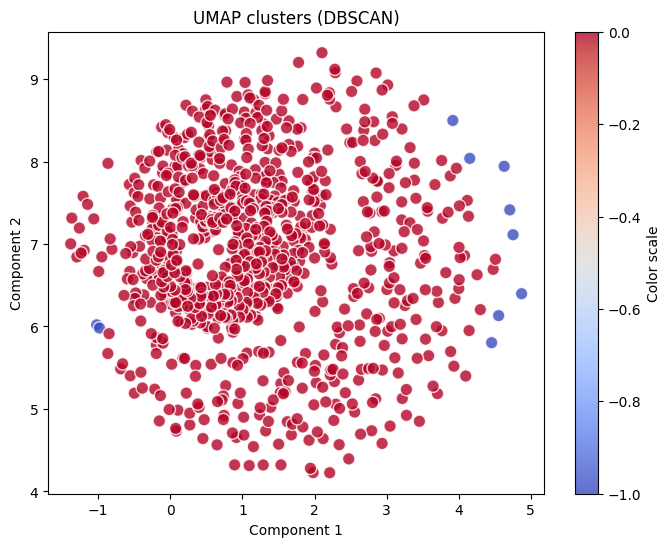

In [41]:
plot_2d_projection(
    umap_result,
    color=df['cluster'],
    title="UMAP clusters (DBSCAN)"
)


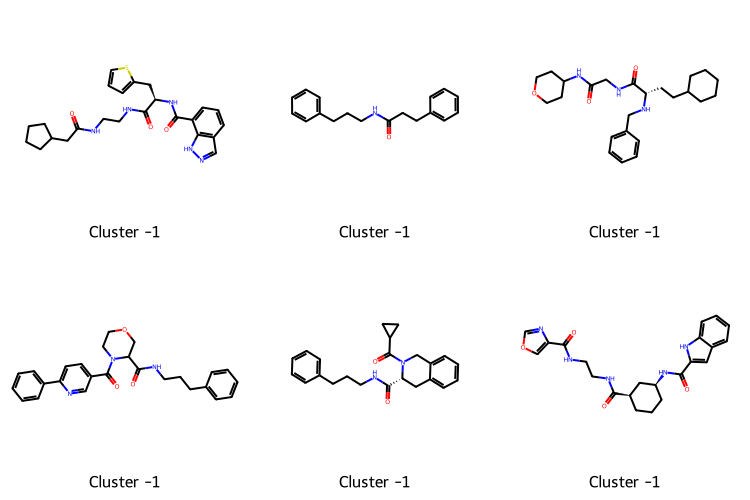

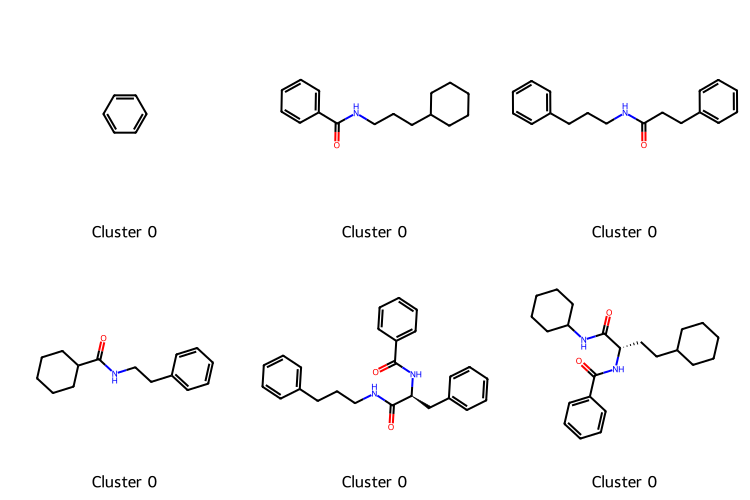

In [42]:
from rdkit.Chem import Draw

for cid in top_clusters:
    scaffolds = (
        top_chemotypes[top_chemotypes['cluster'] == cid]
        .groupby('scaffold')
        .size()
        .sort_values(ascending=False)
        .head(6)
        .index
    )
    mols = [Chem.MolFromSmiles(s) for s in scaffolds if s]
    img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(250,250),
                               legends=[f"Cluster {cid}" for _ in mols])
    display(img)


In [43]:
report = (
    top_chemotypes.groupby(['cluster', 'scaffold'])
    .agg(mean_enrichment=('log_enrichment','mean'),
         n_molecules=('smiles','count'),
         example_smiles=('smiles','first'))
    .reset_index()
)

report = report.merge(
    cluster_summary[['mean_enrichment','n_molecules']],
    on='cluster', suffixes=('_scaffold','_cluster')
)

report.head(10)


,cluster,scaffold,mean_enrichment_scaffold,n_molecules_scaffold,example_smiles,mean_enrichment_cluster,n_molecules_cluster
0,-1,O=C(CC1CCCC1)NCCNC(=O)[C@@H](Cc1cccs1)NC(=O)c1...,0.812913,1,CNC(=O)[C@H](CNC(=O)[C@@H](Cc1cccs1)NC(=O)c1cc...,0.689725,10
1,-1,O=C(CCc1ccccc1)NCCCc1ccccc1,0.937852,1,C#CCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CCc1...,0.689725,10
2,-1,O=C(CNC(=O)[C@H](CCC1CCCCC1)NCc1ccccc1)NC1CCOCC1,0.053246,1,CNC(=O)CC[C@H](NC(=O)[C@H](CCC1CCCCC1)NCc1cccc...,0.689725,10
3,-1,O=C(NCCCc1ccccc1)C1COCCN1C(=O)c1ccc(-c2ccccc2)nc1,0.716003,1,CNC(=O)[C@H](CCc1ccccc1)NC(=O)C1COCCN1C(=O)c1c...,0.689725,10
4,-1,O=C(NCCCc1ccccc1)[C@H]1Cc2ccccc2CN1C(=O)C1CC1,0.937852,1,CNC(=O)[C@H](CCc1ccccc1)NC(=O)[C@H]1Cc2ccccc2C...,0.689725,10
5,-1,O=C(NCCNC(=O)[C@@H]1CCC[C@H](NC(=O)c2cc3ccccc3...,0.812913,1,CNC(=O)[C@@H](CNC(=O)[C@@H]1CCC[C@H](NC(=O)c2c...,0.689725,10
6,-1,O=C(NCCNC(=O)[C@H](CC1CCCCC1)NCc1ccccc1)c1cscn1,0.812913,1,CNC(=O)[C@H](CNC(=O)[C@H](CC1CCCCC1)NCc1cc(OC(...,0.689725,10
7,-1,O=C(NCCNC(=O)[C@H](CCC1CCCCC1)NC(=O)c1cc2c(s1)...,0.238882,1,CNC(=O)[C@@H](CNC(=O)[C@H](CCC1CCCCC1)NC(=O)c1...,0.689725,10
8,-1,O=C(N[C@@H](Cc1ccccc1)C(=O)N1CCN(Cc2cncnc2)CC1...,0.937852,1,CNC(=O)CC1CN(C(=O)[C@H](Cc2cccc(C(F)(F)F)c2)NC...,0.689725,10
9,-1,c1ccccc1,0.636822,1,CCCCCCC(O)C(=O)N[C@@H](CCC(N)=O)C(=O)N[C@@H](C...,0.689725,10


### Medoids

In [45]:
from rdkit.DataStructs import TanimotoSimilarity

def tanimoto_matrix(fps):
    """Compute pairwise Tanimoto similarity for a list of RDKit fingerprints."""
    n = len(fps)
    sim_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            sim = TanimotoSimilarity(fps[i], fps[j])
            sim_matrix[i, j] = sim
            sim_matrix[j, i] = sim
    return sim_matrix


In [46]:
medoids = {}

for cid in top_clusters:
    cluster_df = top_chemotypes[top_chemotypes['cluster'] == cid].copy()
    # Convert SMILES to fingerprints
    fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(s)) for s in cluster_df['smiles']]
    
    # Compute pairwise Tanimoto similarity
    sim_matrix = tanimoto_matrix(fps)
    
    # Compute sum of similarities per molecule
    sim_sums = sim_matrix.sum(axis=1)
    
    # Medoid = molecule with highest total similarity to others
    medoid_idx = sim_sums.argmax()
    medoids[cid] = cluster_df.iloc[medoid_idx]['smiles']
    
medoids


{-1: 'CNC(=O)CC1CN(C(=O)[C@H](Cc2cccc(C(F)(F)F)c2)NC(=O)c2cc3cccc(F)c3[nH]2)CCN1Cc1cncnc1',
 0: 'CNC(=O)[C@@H]1C[C@@H](NC(=O)c2ccncc2)CN1C(=O)[C@H](Cc1ccccc1Cl)NC(=O)[C@H]1CC[C@H](C(C)(C)C)CC1'}

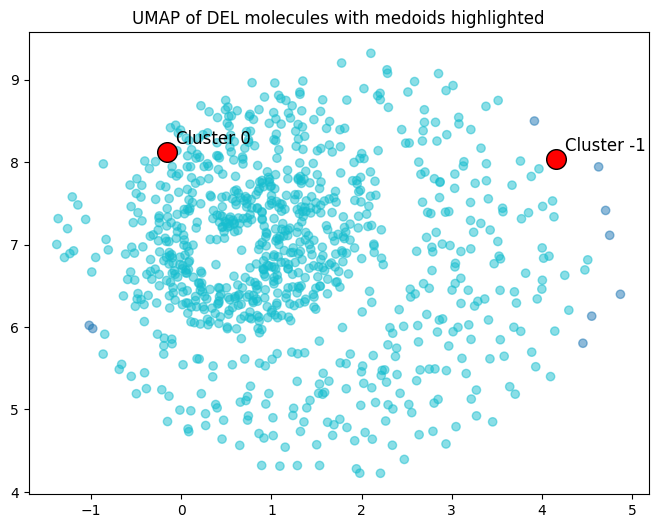

In [47]:
plt.figure(figsize=(8,6))
plt.scatter(umap_result[:,0], umap_result[:,1], c=df['cluster'], cmap='tab10', alpha=0.5)

for cid, smi in medoids.items():
    idx = df[df['smiles'] == smi].index[0]
    plt.scatter(umap_result[idx,0], umap_result[idx,1], c='red', s=200, edgecolors='k')
    plt.text(umap_result[idx,0]+0.1, umap_result[idx,1]+0.1, f"Cluster {cid}", fontsize=12)

plt.title("UMAP of DEL molecules with medoids highlighted")
plt.show()


In [48]:
from rdkit.Chem.Scaffolds import MurckoScaffold

medoid_summary = []

for cid, smi in medoids.items():
    mol = Chem.MolFromSmiles(smi)
    if mol:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        scaffold_smi = Chem.MolToSmiles(scaffold)
    else:
        scaffold_smi = None
    
    medoid_summary.append({
        'cluster': cid,
        'medoid_smiles': smi,
        'scaffold_smiles': scaffold_smi,
        'cluster_size': len(top_chemotypes[top_chemotypes['cluster'] == cid]),
        'mean_enrichment': top_chemotypes[top_chemotypes['cluster'] == cid]['log_enrichment'].mean()
    })

medoid_df = pd.DataFrame(medoid_summary)
medoid_df.sort_values('mean_enrichment', ascending=False, inplace=True)
medoid_df


,cluster,medoid_smiles,scaffold_smiles,cluster_size,mean_enrichment
0,-1,CNC(=O)CC1CN(C(=O)[C@H](Cc2cccc(C(F)(F)F)c2)NC...,O=C(N[C@@H](Cc1ccccc1)C(=O)N1CCN(Cc2cncnc2)CC1...,10,0.689725
1,0,CNC(=O)[C@@H]1C[C@@H](NC(=O)c2ccncc2)CN1C(=O)[...,O=C(N[C@@H]1CCN(C(=O)[C@H](Cc2ccccc2)NC(=O)C2C...,884,0.500413


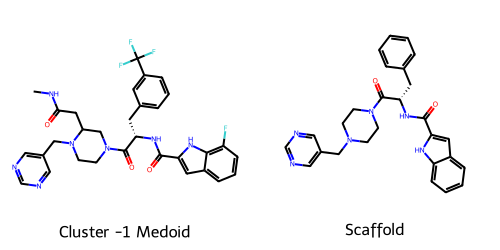

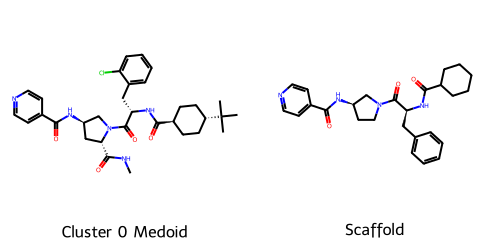

In [49]:
from rdkit.Chem import Draw

for _, row in medoid_df.iterrows():
    mol_medoid = Chem.MolFromSmiles(row['medoid_smiles'])
    mol_scaffold = Chem.MolFromSmiles(row['scaffold_smiles'])
    img = Draw.MolsToGridImage(
        [mol_medoid, mol_scaffold],
        legends=[f"Cluster {row['cluster']} Medoid", "Scaffold"],
        molsPerRow=2, subImgSize=(250,250)
    )
    display(img)


In [50]:
from rdkit.DataStructs import TanimotoSimilarity
from rdkit import Chem
from rdkit.Chem import AllChem

def compute_fingerprint(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    return None

# Add a column for medoid SMILES per molecule
df['cluster_medoid'] = df['cluster'].map(medoids)

# Compute Tanimoto similarity of each molecule to its medoid
def similarity_to_medoid(row):
    fp_mol = compute_fingerprint(row['smiles'])
    fp_medoid = compute_fingerprint(row['cluster_medoid'])
    if fp_mol and fp_medoid:
        return TanimotoSimilarity(fp_mol, fp_medoid)
    else:
        return np.nan

df['tanimoto_to_medoid'] = df.apply(similarity_to_medoid, axis=1)


In [51]:
cluster_summary = df.groupby('cluster').agg(
    cluster_size=('smiles', 'count'),
    mean_tanimoto=('tanimoto_to_medoid', 'mean'),
    median_tanimoto=('tanimoto_to_medoid', 'median'),
    mean_enrichment=('log_enrichment', 'mean')
).reset_index()

cluster_summary.sort_values('mean_tanimoto', ascending=False, inplace=True)
cluster_summary


,cluster,cluster_size,mean_tanimoto,median_tanimoto,mean_enrichment
0,-1,10,0.307325,0.221767,0.689725
1,0,884,0.278818,0.255870,0.500413


/tmp/ipykernel_9757/2986289115.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


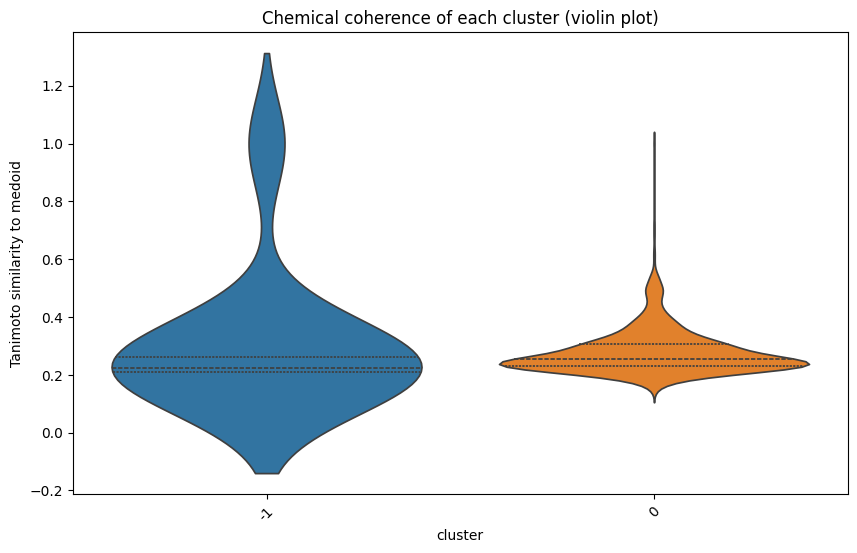

In [56]:
plt.figure(figsize=(10,6))
sns.violinplot(
    x='cluster', 
    y='tanimoto_to_medoid', 
    data=df, 
    inner='quartile', 
    palette='tab10'
)
plt.xticks(rotation=45)
plt.ylabel("Tanimoto similarity to medoid")
plt.title("Chemical coherence of each cluster (violin plot)")
plt.show()
